# NODE – Neural Oblivious Decision Ensembles

This notebook demonstrates how to use the **NODE** module in Mother for tabular regression and classification.
NODE combines differentiable oblivious decision trees with deep learning, offering:

- **Competitive accuracy** on tabular data (comparable to gradient-boosted trees)
- **Multiple head architectures** – subset, linear, MLP, and flow (probabilistic)
- **Uncertainty quantification** – MC Dropout (all heads) + flow-based aleatoric uncertainty
- **Learned embeddings** for downstream tasks (UMAP, clustering, transfer learning)
- **Full sklearn compatibility** – `fit` / `predict` / `predict_proba` / pipelines
- **Hyperparameter tuning** via `MotherTuner` integration

---

### Architecture overview

```
Input Data → Embedding Layer → Dense ODST Blocks → Head → Predictions
                                                    ├─ subset  (default clf)
                                                    ├─ linear
                                                    ├─ mlp     (default reg)
                                                    └─ flow    (probabilistic, reg only)
```

### Table of contents

| # | Section | |
|---|---------|---|
| 1 | Architecture Deep Dive | Sparse activations, ODST trees, dense connections |
| 2 | Quick Start – Regression | Fit a NODE regressor in 5 lines |
| 3 | Quick Start – Classification | Binary and multiclass |
| 4 | Head Types Compared | subset · linear · mlp · flow |
| 5 | Flow Head – Probabilistic Regression | Sampling, density plots |
| 6 | Uncertainty Estimation | MC Dropout, flow, combined decomposition |
| 7 | Learned Embeddings & UMAP | Visualise tree representations |
| 8 | Multi-Target Regression | Multiple outputs, NaN masking |
| 9 | Class Weights & Imbalanced Data | Weighted classification |
| 10 | Multi-Label Classification | BCEWithLogitsLoss multi-label |
| 11 | Standalone Heads | MLPHeadRegressor · MLPHeadClassifier · FlowHeadRegressor |
| 12 | SHAP Explanations | GradientExplainer, KernelExplainer, waterfall |
| 13 | Advanced Topics | DataFrame/categorical support, embeddings→head pipeline, skorch, device |
| 14 | Hyperparameter Tuning with MotherTuner | Optuna integration |

---
## 1  Architecture Deep Dive

### Sparse Activations

NODE uses **sparse** activation functions that produce exact zeros, making trees naturally select only a few features per split:

| Function | Role | Description |
|----------|------|-------------|
| `entmax15` | Feature selection (`choice_function`) | Projects onto the 1.5-simplex — produces exact zeros |
| `sparsemax` | Feature selection (alternative) | Projects onto the probability simplex |
| `entmoid15` | Bin boundaries (`bin_function`) | Sparse sigmoid-like |
| `sparsemoid` | Bin boundaries (alternative) | Hard sigmoid variant |

The defaults (`entmax15` + `entmoid15`) mean each tree only attends to a small subset of features, improving interpretability.

### ODST — Oblivious Decision Stump Trees

Each tree is **oblivious**: all nodes at the same depth share the same split feature and threshold.
This makes each tree equivalent to a lookup table of size $2^{\text{depth}}$.

$$\text{output} = \sum_{l=1}^{2^d} w_l \cdot \mathbb{1}[\text{sample reaches leaf } l]$$

where $w_l$ is the learned response vector and the indicator is **soft** (differentiable) via the bin function.

### Dense Connections

The `DenseODSTBlock` stacks ODST layers with DenseNet-style connections:

```
Layer 1 input:  [X]           →  output h₁
Layer 2 input:  [X, h₁]      →  output h₂
Layer 3 input:  [X, h₁, h₂]  →  output h₃
```

Later layers see everything earlier layers learned, enabling iterative refinement.

### Constructor parameter reference

#### NODERegressor (key parameters)

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `num_trees` | int | 2048 | Trees in the ensemble |
| `depth` | int | 6 | Tree depth ($2^d$ leaves each) |
| `num_layers` | int | 1 | Stacked ODST layers |
| `head_type` | str | `"mlp"` | `"subset"` / `"linear"` / `"mlp"` / `"flow"` |
| `mlp_hidden_dims` | list | `[128,64,32]` | MLP head layer sizes |
| `flow_type` | str | `"CNF"` | `"CNF"` / `"MAF"` / `"NSF"` / `"NICE"` |
| `flow_transforms` | int | 3 | Number of flow layers |
| `flow_bins` | int | 8 | Spline bins (NSF only) |
| `input_dropout` | float | 0.1 | Input dropout (needed for MC Dropout UQ) |
| `tree_dropout` | float | 0.0 | Dropout on tree outputs |
| `mlp_dropout` | float | 0.1 | Dropout in MLP head |
| `max_epochs` | int | 100 | Training epochs |
| `lr` | float | 0.01 | Learning rate |
| `batch_size` | int | 128 | Batch size |
| `target_type` | str | `"single_target"` | `"single_target"` or `"multi_target"` |
| `task_weights` | list | None | Per-target loss weights |

#### NODEClassifier differences

| Parameter | Regressor default | Classifier default |
|-----------|-------------------|-------------------|
| `head_type` | `"mlp"` | `"subset"` |
| `input_dropout` | 0.1 | 0.0 |
| `criterion` | `MSELoss` | `CrossEntropyLoss` |
| Flow head | ✅ supported | ❌ not supported |

## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

# NODE
from mother.ml.models.m_node import NODERegressor, NODEClassifier

# Standalone heads
from mother.ml.models.m_heads import (
    MLPHeadRegressor,
    MLPHeadClassifier,
    FlowHeadRegressor,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Helper – synthetic datasets

In [2]:
def get_regression_data(n=400, n_features=10):
    """Create a simple regression dataset."""
    X, y = make_regression(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        noise=10,
        random_state=RANDOM_STATE,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    # Standardise targets (important for flow heads)
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.float32),
        y_test.astype(np.float32),
        y_scaler,
    )


def get_classification_data(n=400, n_features=10, n_classes=2, weights=None):
    """Create a classification dataset."""
    X, y = make_classification(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        n_redundant=2,
        n_classes=n_classes,
        random_state=RANDOM_STATE,
        weights=weights,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    return X_train.astype(np.float32), X_test.astype(np.float32), y_train, y_test

---
## 2  Quick Start – Regression

In [3]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

reg = NODERegressor(
    num_trees=256,
    depth=4,
    num_layers=1,
    head_type="mlp",
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
reg.fit(X_train, y_train)

preds = reg.predict(X_test)
print(f"R² = {r2_score(y_test, preds):.4f}")
print(f"RMSE = {mean_squared_error(y_test, preds, squared=False):.4f}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        1.1100  0.8074
      2        0.4530  0.0903
      3        0.2830  0.0840
      4        0.2948  0.0879
      5        0.2649  0.0840
      6        0.2320  0.0851
      7        0.2281  0.0877
      8        0.1884  0.0855
      9        0.1535  0.0865
     10        0.1786  0.1012
     11        0.1835  0.0934
     12        0.1350  0.0849
     13        0.1693  0.0853
     14        0.1531  0.0868
     15        0.1332  0.1171
     16        0.1596  0.0919
     17        0.1441  0.0833
     18        0.1418  0.0904
     19        0.1629  0.0858
     20        0.2061  0.0809
R² = 0.9843
RMSE = 0.1091


In [4]:
# Inspect the full PyTorch module tree (ODST ensemble → MLP head)
reg.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=4, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): MLPHead(
    (mlp): Sequential(
      (0): Linear(in_features=1024, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

---
## 3  Quick Start – Classification

In [5]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data()

clf = NODEClassifier(
    num_trees=256,
    depth=4,
    num_layers=1,
    head_type="subset",  # default for classification
    input_dropout=0.1,  # enables MC-Dropout uncertainty
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf.fit(X_train_c, y_train_c)

preds_c = clf.predict(X_test_c)
probas = clf.predict_proba(X_test_c)

print(f"Accuracy = {accuracy_score(y_test_c, preds_c):.4f}")
print(f"Probabilities shape: {probas.shape}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6912  0.4837
      2        0.6799  0.1027
      3        0.6687  0.0909
      4        0.6563  0.0943
      5        0.6456  0.0854
      6        0.6346  0.1274
      7        0.6223  0.1298
      8        0.6115  0.1268
      9        0.5960  0.1300
     10        0.5806  0.1266
     11        0.5706  0.1242
     12        0.5560  0.1420
     13        0.5403  0.1615
     14        0.5258  0.1433
     15        0.5152  0.1191
     16        0.5091  0.1281
     17        0.4891  0.1670
     18        0.4736  0.1560
     19        0.4721  0.1455
     20        0.4693  0.1617
Accuracy = 0.7375
Probabilities shape: (80, 2)


In [6]:
# Architecture with subset head (default for classification)
clf.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=5, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): Lambda()
)

---
## 4  Head Types Compared

NODE supports four head architectures.  Each one converts the tree ensemble output into final predictions.

| Head | How it works | Default for | Flow-based UQ? |
|------|-------------|-------------|----------------|
| **subset** | Averages a learned subset of tree outputs | Classification | No |
| **linear** | Single linear layer on flattened tree outputs | – | No |
| **mlp** | Multi-layer perceptron on flattened tree outputs | Regression | No |
| **flow** | Conditional normalising flow on tree embeddings | – (reg only) | **Yes** |

Each head receives the same tree embeddings but produces predictions differently:

```
                    ODST Ensemble Output  [batch, num_trees × depth]
                              │
          ┌───────────┬───────┴────────┬──────────────┐
          ▼           ▼                ▼              ▼
     ┌─────────┐ ┌─────────┐   ┌────────────┐  ┌──────────────┐
     │ SUBSET  │ │ LINEAR  │   │    MLP     │  │     FLOW     │
     │         │ │         │   │            │  │              │
     │ Wᵢ·hᵢ  │ │  W·h+b  │   │ h→BN→Act  │  │  x ──► p(y|x)│
     │  avg    │ │         │   │  →Drop     │  │  conditional │
     │  pool   │ │         │   │  × layers  │  │  normalizing │
     │         │ │         │   │            │  │  flow        │
     └────┬────┘ └────┬────┘   └─────┬──────┘  └──────┬───────┘
          ▼           ▼              ▼                ▼
       ŷ ∈ ℝ      ŷ ∈ ℝᵈ        ŷ ∈ ℝᵈ       dist.sample()
```

$\hat{y}_{\text{subset}} = \frac{1}{|S|}\sum_{i \in S} w_i \cdot h_i \qquad \hat{y}_{\text{linear}} = W h + b \qquad \hat{y}_{\text{mlp}} = \text{MLP}(h)$

In [7]:
import gc

X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

results = {}

for head in ["subset", "linear", "mlp", "flow"]:
    print(f"\n--- head_type = '{head}' ---")
    model = NODERegressor(
        num_trees=256,
        depth=4,
        head_type=head,
        flow_type="NSF" if head == "flow" else "CNF",
        max_epochs=20,
        lr=0.01,
        device="cpu",
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[head] = r2
    print(f"  R² = {r2:.4f}")
    del model
    gc.collect()

print("\n=== Summary ===")
for head, r2 in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {head:8s}  R² = {r2:.4f}")


--- head_type = 'subset' ---
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.9945  0.4738
      2        0.9593  0.0808
      3        0.9307  0.0720
      4        0.8968  0.0741
      5        0.8634  0.0998
      6        0.8247  0.1362
      7        0.7947  0.1072
      8        0.7557  0.1625
      9        0.7104  0.1362
     10        0.6693  0.1545
     11        0.6369  0.1496
     12        0.5726  0.1368
     13        0.5255  0.1199
     14        0.4893  0.1539
     15        0.4492  0.1476
     16        0.3970  0.1503
     17        0.3337  0.1332
     18        0.3212  0.1251
     19        0.2959  0.1470
     20        0.2631  0.1334
  R² = 0.7849

--- head_type = 'linear' ---
Re-initializing module because the following parameters were re-set: module__head_typ

---
## 5  Flow Head – Probabilistic Regression

The **flow head** models the full conditional distribution $p(y \mid x)$ using normalising flows.
This lets you:

- Draw samples from the predictive distribution
- Estimate quantiles, credible intervals, or density plots
- Decompose uncertainty into **aleatoric** (data) and **epistemic** (knowledge) components

### How normalizing flows work

A flow transforms a simple base distribution $z \sim \mathcal{N}(0, I)$ into a complex
target distribution through a chain of invertible transformations:

```
  z ~ N(0,I)  ──► T₁ ──► T₂ ──► T₃ ──►  y ~ p(y|x)
       │            │       │       │          │
   base dist   transform  ...   transform   learned
   (simple)    (invertible)      (invertible) distribution

```

The loss is the **negative log-likelihood** under the change-of-variables formula:

$$\log p(y \mid x) = \log p_z\bigl(T^{-1}(y)\bigr) + \sum_{k=1}^{K} \log \left|\det \frac{\partial T_k^{-1}}{\partial T_{k-1}}\right|$$

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log p(y_i \mid x_i)$$

Supported flow types (via the [zuko](https://github.com/probabilists/zuko) library):

| Flow | Description | Notes |
|------|-------------|-------|
| `CNF` | Continuous Normalising Flow | Default, flexible |
| `MAF` | Masked Autoregressive Flow | Good density estimation |
| `NSF` | Neural Spline Flow | **Recommended** – best quality/speed tradeoff |
| `NICE` | Non-linear Independent Components | Simple and fast |

> **Tip:** Always standardise your targets before training with a flow head for numerical stability.

In [8]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_model = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="flow",
    flow_type="NSF",  # Neural Spline Flow (recommended)
    flow_transforms=3,
    flow_bins=8,
    input_dropout=0.1,  # enables MC Dropout for combined UQ
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
flow_model.fit(X_train, y_train)

# Point predictions (mode of the distribution)
preds_flow = flow_model.predict(X_test)
print(f"Flow R² = {r2_score(y_test, preds_flow):.4f}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        3.5344  0.3850
      2        5.3403  0.1401
      3        2.9770  0.1037
      4        2.8704  0.1156
      5        2.7564  0.1007
      6        1.8590  0.1567
      7        1.6264  0.0984
      8        1.2915  0.1025
      9        0.8500  0.0994
     10        0.7395  0.1036
     11        0.5201  0.1029
     12        0.3912  0.1077
     13        0.4413  0.1494
     14        0.4677  0.1246
     15        0.5381  0.1147
     16        0.4088  0.1224
     17        0.3808  0.1307
     18        0.2238  0.1373
     19        0.1802  0.1321
     20        0.1691  0.1228
Flow R² = 0.9616


In [9]:
# Architecture with normalising-flow head (NSF)
flow_model.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=4, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): FlowHead(
    (net): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=1024, out_features=64, bias=True)
            (1): ReLU()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
    )
  )
)

### 5.1  Sampling from the flow distribution

Access the underlying flow distribution to draw samples from $p(y \mid x)$ and visualise
the predictive density for individual test points.

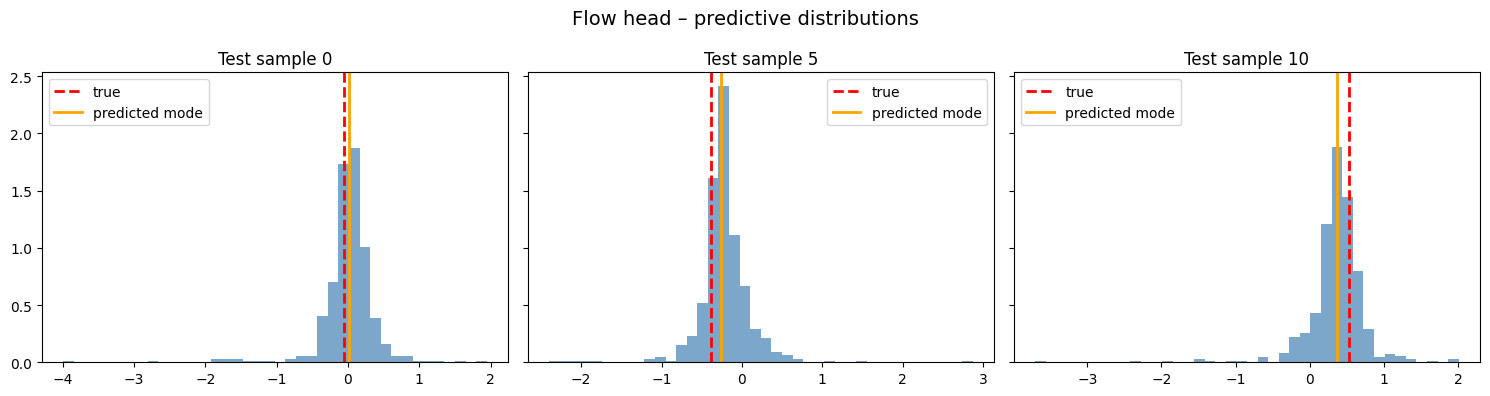

In [10]:
import torch

flow_model.module_.eval()

# Pick a few test points to visualise
idx = [0, 5, 10]
X_subset = X_test[idx]
X_tensor = torch.tensor(X_subset, dtype=torch.float32)

with torch.no_grad():
    dist = flow_model.module_(X_tensor)
    samples = dist.sample((500,)).squeeze(-1).cpu().numpy()  # (500, len(idx))

fig, axes = plt.subplots(1, len(idx), figsize=(5 * len(idx), 4), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(samples[:, i], bins=40, density=True, alpha=0.7, color="steelblue")
    ax.axvline(y_test[idx[i]], color="red", ls="--", lw=2, label="true")
    ax.axvline(preds_flow[idx[i]], color="orange", ls="-", lw=2, label="predicted mode")
    ax.set_title(f"Test sample {idx[i]}")
    ax.legend()
fig.suptitle("Flow head – predictive distributions", fontsize=14)
plt.tight_layout()
plt.show()

---
## 6  Uncertainty Estimation

NODE supports three uncertainty modes, all accessed through the **standardised
`predict_uncertainty()` interface** (matching TabPFN, RandomForest, and CatBoost):

```
                          predict_uncertainty(X)
                                  │
                 ┌────────────────┼────────────────┐
                 ▼                ▼                ▼
          ┌────────────┐  ┌────────────┐  ┌─────────────────┐
          │ MC Dropout │  │   Flow     │  │    Combined     │
          │            │  │  Sampling  │  │  (Flow+Dropout) │
          │ N forward  │  │ draw from  │  │  MC passes ×    │
          │ passes w/  │  │ p(y|x) via │  │  flow samples   │
          │ stochastic │  │ learned    │  │  per pass       │
          │ dropout    │  │ distribtn  │  │                 │
          └─────┬──────┘  └─────┬──────┘  └───────┬─────────┘
                │               │                 │

                ▼               ▼                 ▼
           σ_epistemic     σ_aleatoric    σ_epist + σ_aleat
          (knowledge)       (data)         (decomposed)
```

| Method | Head types | What it captures | API |
|--------|-----------|-----------------|-----|
| **MC Dropout** | All (need `input_dropout > 0`) | Epistemic (knowledge) | `predict_uncertainty()` |
| **Flow sampling** | Flow only | Aleatoric (data) | `predict_uncertainty()` |
| **Combined decomposition** | Flow + dropout | Both, decomposed | `predict_with_combined_uncertainty()` |

**Key parameters** (same signature as TabPFN / RandomForest):

| Parameter | Default | Description |
|-----------|---------|-------------|
| `num_samples` | `100` | MC Dropout forward passes (or flow samples) |
| `return_quantiles` | `False` | If `True`, also return `(DataFrame, quantile_array)` |
| `quantiles` | `[0.25, 0.5, 0.75]` | Quantiles to compute (only when `return_quantiles=True`) |
| `uncertainty_for_opt` | `False` | If `True`, return only `total_uncertainty` as `pd.Series` |

### MC Dropout — the math

Given $N$ stochastic forward passes with different dropout masks $\theta_i$:

$\hat{y} = \frac{1}{N}\sum_{i=1}^{N} f_{\theta_i}(x) \qquad \sigma_{\text{epistemic}} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} \bigl(f_{\theta_i}(x) - \hat{y}\bigr)^2}$

### Flow uncertainty — the math

The aleatoric uncertainty comes from the negative log-probability of the mode:

$\hat{y}_{\text{mode}} = \arg\max_{y_j} \log p(y_j \mid x), \quad y_j \sim p(y \mid x)$

$\sigma_{\text{aleatoric}} = -\log p(\hat{y}_{\text{mode}} \mid x)$


### 6.1  MC Dropout uncertainty (any head)

In [11]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

model_mlp = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="mlp",
    input_dropout=0.1,  # required for MC Dropout
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
model_mlp.fit(X_train, y_train)

df_unc = model_mlp.predict_uncertainty(X_test, num_samples=30)
print(df_unc.head())
print(f"\nColumns: {list(df_unc.columns)}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        1.0772  0.4604
      2        0.4744  0.0851
      3        0.2857  0.0844
      4        0.2166  0.0824
      5        0.2132  0.0830
      6        0.2351  0.0809
      7        0.1823  0.0821
      8        0.2348  0.0891
      9        0.1818  0.0919
     10        0.1714  0.0846
     11        0.1894  0.0930
     12        0.1518  0.1125
     13        0.2077  0.0970
     14        0.1791  0.1104
     15        0.1867  0.0909
     16        0.1624  0.1093
     17        0.1219  0.1145
     18        0.1584  0.1255
     19        0.1854  0.0829
     20        0.1414  0.0862
   mean_predictions  knowledge_uncertainty data_uncertainty  total_uncertainty
0         -0.061888               0.505213             None           0.505213
1

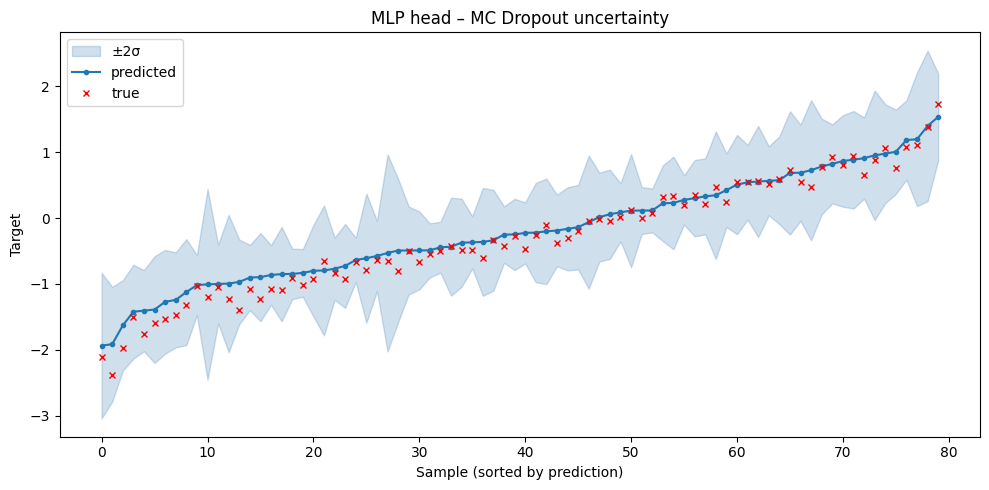

In [12]:
# Plot predictions with uncertainty bands
sort_idx = np.argsort(df_unc["mean_predictions"].values)
preds_sorted = df_unc["mean_predictions"].values[sort_idx]
unc_sorted = df_unc["total_uncertainty"].values[sort_idx]
true_sorted = y_test[sort_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    range(len(preds_sorted)),
    preds_sorted - 2 * unc_sorted,
    preds_sorted + 2 * unc_sorted,
    alpha=0.25,
    color="steelblue",
    label="±2σ",
)
ax.plot(preds_sorted, "o-", ms=3, label="predicted")
ax.plot(true_sorted, "x", ms=4, color="red", label="true")
ax.set_xlabel("Sample (sorted by prediction)")
ax.set_ylabel("Target")
ax.set_title("MLP head – MC Dropout uncertainty")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2  Flow-based uncertainty

In [13]:
# Re-use flow_model from Section 4 (already trained with input_dropout=0.1)
df_flow_unc = flow_model.predict_uncertainty(
    X_test,
    num_samples=50,
    return_quantiles=True,
    quantiles=[0.025, 0.5, 0.975],
)

# predict_uncertainty with return_quantiles returns a tuple: (DataFrame, quantile_array)
if isinstance(df_flow_unc, tuple):
    df_flow, quantiles_arr = df_flow_unc
else:
    df_flow = df_flow_unc
    quantiles_arr = None

print(df_flow.head())
print(f"\nData uncertainty available: {df_flow['data_uncertainty'].notna().any()}")
print(f"Knowledge uncertainty available: {df_flow['knowledge_uncertainty'].notna().any()}")

   mean_predictions  knowledge_uncertainty  data_uncertainty  \
0         -0.096903               3.242890         -0.779207   
1         -0.515004               3.899343         -0.773686   
2         -0.174350               3.797770         -0.858620   
3         -0.178664               4.622704         -0.805260   
4         -0.111688               2.913144         -0.740815   

   total_uncertainty  
0           2.463684  
1           3.125658  
2           2.939149  
3           3.817443  
4           2.172330  

Data uncertainty available: True
Knowledge uncertainty available: True


### 6.3  Combined uncertainty decomposition (flow + dropout)

When using a **flow head** with **dropout > 0**, you can decompose total uncertainty into:

- **Data (aleatoric)** uncertainty – irreducible noise in the data
- **Knowledge (epistemic)** uncertainty – model uncertainty, reducible with more data

```
                  ┌─── MC pass 1 (dropout mask θ₁) ──► flow.sample() ──► σ_data₁
                  │
  X ──────────────┼─── MC pass 2 (dropout mask θ₂) ──► flow.sample() ──► σ_data₂
                  │
                  └─── MC pass N (dropout mask θₙ) ──► flow.sample() ──► σ_dataₙ
                                                                             │
                        Data uncertainty = median(σ_data₁ ... σ_dataₙ)  ◄────┤
                        Knowledge unc.   = IQR(σ_data₁ ... σ_dataₙ)    ◄────┘
```

This is available through `predict_with_combined_uncertainty()`.

$\sigma_{\text{data}} = \text{median}_i\bigl(-\log p_{\theta_i}(\hat{y}_i \mid x)\bigr)$

$\sigma_{\text{knowledge}} = Q_{0.75} - Q_{0.25} \quad \text{of} \quad \bigl\{-\log p_{\theta_i}(\hat{y}_i \mid x)\bigr\}_{i=1}^{N}$

In [14]:
predictions, knowledge_unc, data_unc = flow_model.predict_with_combined_uncertainty(
    X_test,
    num_mc_samples=20,
    num_flow_samples=50,
)

print(f"Predictions shape:           {predictions.shape}")
print(f"Knowledge uncertainty shape: {knowledge_unc.shape if knowledge_unc is not None else 'None'}")
print(f"Data uncertainty shape:      {data_unc.shape}")
print(f"\nMean data uncertainty:      {data_unc.mean():.4f}")
if knowledge_unc is not None:
    print(f"Mean knowledge uncertainty: {knowledge_unc.mean():.4f}")

Predictions shape:           (80,)
Knowledge uncertainty shape: (80,)
Data uncertainty shape:      (80,)

Mean data uncertainty:      -0.8284
Mean knowledge uncertainty: 3.4200


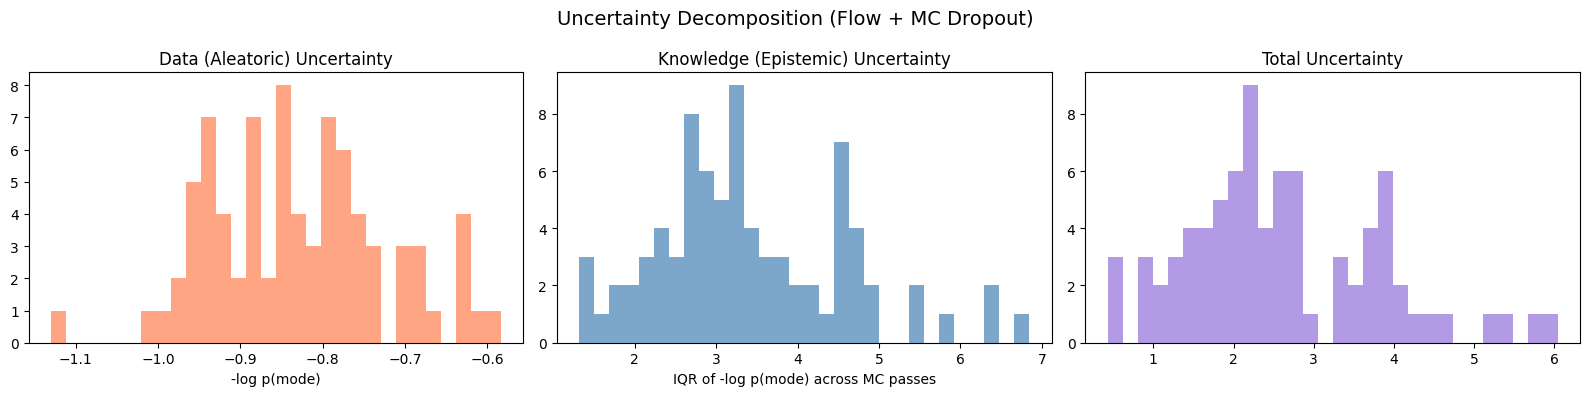

In [15]:
# Visualise the decomposition
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(data_unc, bins=30, alpha=0.7, color="coral")
axes[0].set_title("Data (Aleatoric) Uncertainty")
axes[0].set_xlabel("-log p(mode)")

if knowledge_unc is not None:
    axes[1].hist(knowledge_unc, bins=30, alpha=0.7, color="steelblue")
    axes[1].set_title("Knowledge (Epistemic) Uncertainty")
    axes[1].set_xlabel("IQR of -log p(mode) across MC passes")
else:
    axes[1].text(
        0.5, 0.5, "No dropout → no\nknowledge uncertainty", ha="center", va="center", transform=axes[1].transAxes
    )
    axes[1].set_title("Knowledge Uncertainty (N/A)")

total_unc = data_unc + (knowledge_unc if knowledge_unc is not None else 0)
axes[2].hist(total_unc, bins=30, alpha=0.7, color="mediumpurple")
axes[2].set_title("Total Uncertainty")

fig.suptitle("Uncertainty Decomposition (Flow + MC Dropout)", fontsize=14)
plt.tight_layout()
plt.show()

### 6.4  Classification uncertainty

In [16]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data()

clf_unc = NODEClassifier(
    num_trees=256,
    depth=4,
    input_dropout=0.1,
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf_unc.fit(X_train_c, y_train_c)

df_clf_unc = clf_unc.predict_uncertainty(X_test_c, num_samples=30)
print(df_clf_unc.head())

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6915  0.3924
      2        0.6806  0.1007
      3        0.6699  0.0707
      4        0.6584  0.0770
      5        0.6474  0.0889
      6        0.6363  0.1112
      7        0.6236  0.1071
      8        0.6107  0.1049
      9        0.5943  0.1100
     10        0.5826  0.1055
     11        0.5689  0.1019
     12        0.5480  0.1090
     13        0.5395  0.1057
     14        0.5218  0.1031
     15        0.5152  0.1023
     16        0.4934  0.1242
     17        0.4926  0.1417
     18        0.4818  0.1114
     19        0.4626  0.1051
     20        0.4486  0.1063
   mean_predictions  knowledge_uncertainty data_uncertainty  total_uncertainty
0          0.229155               0.092327             None           0.092327
1

---
## 7  Learned Embeddings & UMAP

NODE's tree layers learn powerful representations of the input data.
Use `get_embeddings()` to extract them for visualisation or downstream tasks.

The embedding dimension is $m = \text{num\_trees} \times \text{depth}$, so a model
with 256 trees and depth 4 yields 1024-dim embeddings.

```
  Raw Features                     Learned Embeddings
  x ∈ ℝⁿ                          e ∈ ℝᵐ  (m = num_trees × depth)
     │                                ▲
     ▼                                │
 ┌───────────────────────────────────────┐
 │             ODST Ensemble             │
 │  x → [Tree₁  Tree₂  ...  Treeₖ]     │
 │       ↓       ↓            ↓         │
 │      h₁      h₂    ...   hₖ         │
 │       └───────┴──────┬────┘          │
 │                      ▼               │
 │              concat(h₁...hₖ)  ═══► e │
 └───────────────────────────────────────┘
                                     │
                                     ▼
                              Downstream uses:
                        ┌──────────────────────────────┐
                        │  • UMAP / t-SNE visualisation│
                        │  • Clustering (KMeans, etc.) │
                        │  • Transfer to new heads     │
                        │  • Similarity search         │
                        └──────────────────────────────┘
```

In [17]:
# Get embeddings from the classifier trained above
embeddings_train = clf_unc.get_embeddings(X_train_c)
embeddings_test = clf_unc.get_embeddings(X_test_c)

print(f"Embedding shape (train): {embeddings_train.shape}")
print(f"Embedding shape (test):  {embeddings_test.shape}")

Embedding shape (train): (320, 1280)
Embedding shape (test):  (80, 1280)


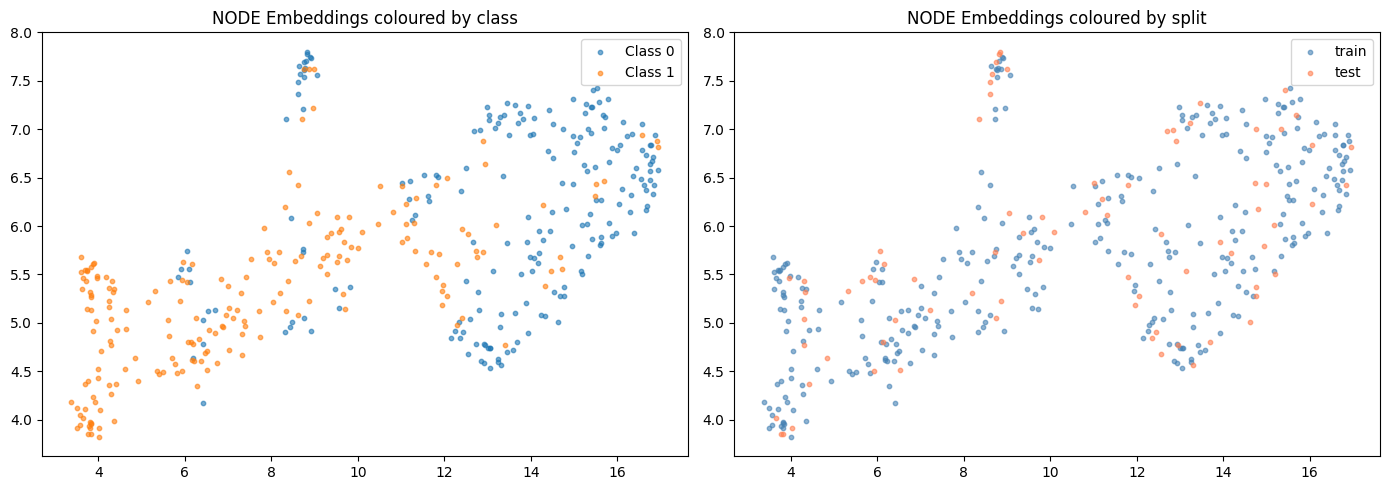

In [18]:
try:
    from umap import UMAP

    # Combine embeddings and labels
    all_embeddings = np.vstack([embeddings_train, embeddings_test])
    all_labels = np.concatenate([y_train_c, y_test_c])
    all_splits = ["train"] * len(y_train_c) + ["test"] * len(y_test_c)

    # Fit UMAP
    reducer = UMAP(n_components=2, random_state=RANDOM_STATE)
    embeddings_2d = reducer.fit_transform(all_embeddings)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By class
    for cls in np.unique(all_labels):
        mask = all_labels == cls
        axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=10, alpha=0.6, label=f"Class {cls}")
    axes[0].set_title("NODE Embeddings coloured by class")
    axes[0].legend()

    # By split
    for split, colour in [("train", "steelblue"), ("test", "coral")]:
        mask = np.array(all_splits) == split
        axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=10, alpha=0.6, label=split, color=colour)
    axes[1].set_title("NODE Embeddings coloured by split")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install `umap-learn` for UMAP visualisation: pip install umap-learn")

---
## 8  Multi-Target Regression

NODE supports multi-target regression natively.  When targets contain `NaN` values,
NODE automatically masks them during loss computation, allowing training on
incomplete label matrices.

where $\mathcal{V}_j = \{i : y_{ij} \neq \text{NaN}\}$ is the set of valid samples for target $j$.

```

  Target matrix Y with missing values:$$\mathcal{L} = \sum_{j=1}^{T} w_j \cdot \frac{1}{|\mathcal{V}_j|}\sum_{i \in \mathcal{V}_j}(\hat{y}_{ij} - y_{ij})^2$$



        Target₁  Target₂  Target₃You can also weight each target's contribution to the loss via `task_weights`:

  x₁ [  1.2      NaN      0.8  ]

  x₂ [  0.5      3.1      NaN  ]```

  x₃ [  NaN      2.4      1.1  ]                 Σᵢ Σⱼ  𝟙[yᵢⱼ ≠ NaN]

  x₄ [  0.9      1.7      0.3  ]          ─────────────────────────────────────

      ℒ = Σᵢ Σⱼ  𝟙[yᵢⱼ ≠ NaN] · (ŷᵢⱼ − yᵢⱼ)²

  Loss computation (NaN-masked MSE):

In [19]:
# Create multi-target data
X_mt, y_mt = make_regression(
    n_samples=400,
    n_features=10,
    n_targets=3,
    noise=10,
    random_state=RANDOM_STATE,
)

# Inject some NaN values to demonstrate masking
y_mt = y_mt.astype(np.float32)
rng = np.random.RandomState(42)
nan_mask = rng.random(y_mt.shape) < 0.1
y_mt[nan_mask] = np.nan
print(f"NaN fraction: {np.isnan(y_mt).mean():.1%}")

X_train_mt, X_test_mt, y_train_mt, y_test_mt = train_test_split(
    X_mt.astype(np.float32),
    y_mt,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

reg_mt = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="mlp",
    target_type="multi_target",
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
reg_mt.fit(X_train_mt, y_train_mt)

preds_mt = reg_mt.predict(X_test_mt)
print(f"\nPredictions shape: {preds_mt.shape}")

# Evaluate per-target (excluding NaN test labels)
for t in range(y_test_mt.shape[1]):
    valid = ~np.isnan(y_test_mt[:, t])
    r2 = r2_score(y_test_mt[valid, t], preds_mt[valid, t])
    print(f"  Target {t}: R² = {r2:.4f}  ({valid.sum()} valid samples)")

NaN fraction: 10.7%
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1    21826.0320  0.4405
      2    21560.6762  0.0945
      3    21284.0879  0.0933
      4    21082.0531  0.1264
      5    20904.3488  0.0930
      6    20792.6437  0.0929
      7    20649.4559  0.0965
      8    20342.9473  0.0956
      9    20047.5459  0.0953
     10    19800.8387  0.1003
     11    19488.7082  0.0970
     12    19264.6578  0.1140
     13    18958.2113  0.1369
     14    18551.4020  0.1562
     15    18169.7219  0.1167
     16    17869.6188  0.1532
     17    17526.3986  0.1124
     18    17203.0238  0.0998
     19    16757.7793  0.0927
     20    16326.6449  0.1032

Predictions shape: (80, 3)
  Target 0: R² = 0.3184  (70 valid samples)
  Target 1: R² = 0.2738  (76 valid samples)
  Target 2: R² = 0.2771

---
## 9  Class Weights & Imbalanced Data

For imbalanced classification, pass weights to `CrossEntropyLoss`.

In [20]:
import torch
import torch.nn as nn

# Create imbalanced dataset (90/10 split)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = get_classification_data(
    n=500,
    weights=[0.9, 0.1],
)

print(f"Class distribution (train): {np.bincount(y_train_imb)}")

# Compute class weights (inverse frequency)
counts = np.bincount(y_train_imb)
class_weights = torch.tensor(
    [len(y_train_imb) / (len(counts) * c) for c in counts],
    dtype=torch.float32,
)
print(f"Class weights: {class_weights}")

clf_weighted = NODEClassifier(
    num_trees=256,
    depth=4,
    max_epochs=20,
    lr=0.01,
    device="cpu",
    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,
)
clf_weighted.fit(X_train_imb, y_train_imb)

preds_imb = clf_weighted.predict(X_test_imb)
print(f"\nAccuracy = {accuracy_score(y_test_imb, preds_imb):.4f}")
print(f"Predicted distribution: {np.bincount(preds_imb)}")

Class distribution (train): [362  38]
Class weights: tensor([0.5525, 5.2632])
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6878  0.5039
      2        0.6740  0.1061
      3        0.6617  0.0998
      4        0.6499  0.1410
      5        0.6349  0.1343
      6        0.6196  0.1326
      7        0.6069  0.1302
      8        0.5894  0.1965
      9        0.5763  0.1326
     10        0.5621  0.1347
     11        0.5438  0.1408
     12        0.5288  0.1524
     13        0.5140  0.1480
     14        0.5001  0.1328
     15        0.4881  0.1328
     16        0.4753  0.1294
     17        0.4627  0.1304
     18        0.4533  0.1372
     19        0.4436  0.1359
     20        0.4303  0.1365

Accuracy = 0.8900
Predicted distribution: [78 22]


---
## 10  Multi-Label Classification

For tasks where each sample can belong to **multiple classes simultaneously**
(e.g. molecule → multiple activity labels), use `NODEClassifier` with
`model_type="classification_multilabel"` and `BCEWithLogitsLoss`.

| Parameter | Value |
|-----------|-------|
| `model_type` | `"classification_multilabel"` |
| `criterion` | `nn.BCEWithLogitsLoss` |
| `y` shape | `(n_samples, n_labels)` with 0/1 values |
| `predict()` | Thresholded at 0.5 |
| `predict_proba()` | Sigmoid probabilities per label |

In [21]:
from sklearn.datasets import make_multilabel_classification
import torch.nn as nn

# Generate synthetic multi-label data (each sample can have multiple labels)
X_ml, y_ml = make_multilabel_classification(
    n_samples=400,
    n_features=10,
    n_classes=4,
    n_labels=2,
    random_state=RANDOM_STATE,
)
X_ml = X_ml.astype(np.float32)
y_ml = y_ml.astype(np.float32)

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
print(f"Train: {X_train_ml.shape}, Labels: {y_train_ml.shape}")
print(f"Avg labels/sample: {y_train_ml.sum(axis=1).mean():.1f}")

clf_ml = NODEClassifier(
    num_trees=256,
    depth=4,
    model_type="classification_multilabel",
    criterion=nn.BCEWithLogitsLoss,
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf_ml.fit(X_train_ml, y_train_ml)

preds_ml = clf_ml.predict(X_test_ml)  # Binary predictions (threshold 0.5)
probas_ml = clf_ml.predict_proba(X_test_ml)  # Sigmoid probabilities

print(f"\nPredictions shape: {preds_ml.shape}")
print(f"Probabilities shape: {probas_ml.shape}")
print(f"Sample prediction: {preds_ml[0]}")
print(f"Sample proba:      {np.round(probas_ml[0], 3)}")

Train: (320, 10), Labels: (320, 4)
Avg labels/sample: 1.7
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6924  0.4608
      2        0.6851  0.0900
      3        0.6781  0.1070
      4        0.6714  0.1096
      5        0.6646  0.1185
      6        0.6580  0.1179
      7        0.6514  0.1134
      8        0.6445  0.1149
      9        0.6377  0.1622
     10        0.6307  0.1185
     11        0.6239  0.1372
     12        0.6165  0.1342
     13        0.6096  0.1143
     14        0.6025  0.2116
     15        0.5957  0.1218
     16        0.5885  0.1330
     17        0.5819  0.1694
     18        0.5752  0.1163
     19        0.5684  0.1198
     20        0.5618  0.1133

Predictions shape: (80, 4)
Probabilities shape: (80, 4)
Sample prediction: [0 1 0 1]
Sample proba:      [0.252 0.72  0.349 0.527]


---
## 11  Standalone Heads

The head architectures (MLP, Flow) are also available as **standalone sklearn-compatible estimators**.
These are useful when:

- You already have pre-computed embeddings (e.g. from a foundation model)
- You want a lightweight model without the full NODE tree layers
- You want to combine heads with your own feature pipeline

```
  ┌──────────────────────────────────────────────────────────┐
  │                  MLPHeadRegressor                        │
  │                                                          │
  │  Input ──► Linear ──► BN ──► ReLU ──► Drop  ← × layers  │
  │                                         │                │
  │                                    Linear ──► ŷ ∈ ℝᵈ    │
  │                                                          │
  │  Loss: MSE     UQ: MC Dropout (σ across N passes)        │
  └──────────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────────┐
  │                  MLPHeadClassifier                       │
  │                                                          │
  │  Input ──► Linear ──► BN ──► ReLU ──► Drop  ← × layers  │
  │                                         │                │
  │                                    Linear ──► softmax    │
  │                                                  │       │
  │  Loss: CrossEntropy    UQ: entropy of avg probs  ▼       │
  │                                          P(class | x)    │
  └──────────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────────┐
  │                  FlowHeadRegressor                       │
  │                                                          │
  │  Input ──context──► Conditional Flow ──► p(y | x)        │
  │                          │                               │
  │                    ┌─────┴─────┐                         │
  │                    │ .sample() │──► regression samples    │
  │                    │.log_prob()│──► NLL uncertainty       │
  │                    └───────────┘                         │
  │  Loss: -log p(y|x)    UQ: aleatoric via NLL             │
  └──────────────────────────────────────────────────────────┘
```

| Class | Task | Key features |
|-------|------|--------------|
| `MLPHeadRegressor` | Regression | AdamW, EarlyStopping, LR scheduling built-in |
| `MLPHeadClassifier` | Classification | Same + CrossEntropyLoss |
| `FlowHeadRegressor` | Probabilistic regression | NLL loss, `predict_flow()` for sampling |

All three support:
- **Auto dimension detection** (via `DimensionSetter` callback – no need to set `input_dim`/`output_dim`)
- **Uncertainty** via `predict_uncertainty()` (MC Dropout)
- **Hyperparameter optimisation** with `suggest_hyperparameters()` + MotherTuner

### 11.1  MLPHeadRegressor

In [22]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

mlp_reg = MLPHeadRegressor(
    hidden_dims=[128, 64, 32],
    dropout=0.1,
    activation="GELU",
    max_epochs=50,
    lr=0.005,
)
mlp_reg.fit(X_train, y_train)

preds_mlp = mlp_reg.predict(X_test)
print(f"MLPHeadRegressor R² = {r2_score(y_test, preds_mlp.flatten()):.4f}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1        0.9585        0.5730  0.0050  0.2764
      2        0.4332        0.3897  0.0050  0.0192
      3        0.2720        0.2237  0.0050  0.0242
      4        0.2355        0.1541  0.0050  0.0322
      5        0.1890        0.1078  0.0050  0.0220
      6        0.2380        0.0829  0.0050  0.0262
      7        0.1445        0.0869  0.0050  0.0177
      8        0.1159        0.0758  0.0050  0.0195
      9        0.1199        0.0575  0.0050  0.0334
     10        0.1044        0.0440  0.0050  0.0365
     11        0.1307        0.0371  0.0050  0.0240
     12        0.0997        0.0352  0.0050  0.0291
     13        0.1341        0.0389  0.0050  0.0226
     14        0.0849        0.0402  0.0050  0.0264
     15        0.0914        0.0433  0.0050  0.0345
     16        0.0868        0.0379  0.0050  0.0242
     17        0.0646        0.0315  0.0050  0.0274
     18     

In [23]:
# Standalone MLP head architecture
mlp_reg.module_

MLPHead(
  (mlp): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

### 11.2  MLPHeadClassifier

In [24]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data(n_classes=3)

mlp_clf = MLPHeadClassifier(
    hidden_dims=[128, 64],
    dropout=0.1,
    activation="ReLU",
    max_epochs=50,
    lr=0.005,
)
mlp_clf.fit(X_train_c, y_train_c)

preds_mlp_clf = mlp_clf.predict(X_test_c)
probas_mlp = mlp_clf.predict_proba(X_test_c)

print(f"MLPHeadClassifier accuracy = {accuracy_score(y_test_c, preds_mlp_clf):.4f}")
print(f"Probability shape: {probas_mlp.shape}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.3535       0.3750        1.2063  0.0050  0.0130
      2        0.8050       0.5000        1.0092  0.0050  0.0207
      3        0.7404       0.5312        0.9335  0.0050  0.0295
      4        0.7080       0.5938        0.8947  0.0050  0.0925
      5        0.6415       0.6250        0.8350  0.0050  0.0278
      6        0.6097       0.6875        0.7791  0.0050  0.0456
      7        0.5956       0.6875        0.7367  0.0050  0.0722
      8        0.5243       0.6875        0.6997  0.0050  0.1

      9        0.5347       0.6875        0.6721  0.0050  0.1355
     10        0.4801       0.6875        0.6420  0.0050  0.0376
     11        0.4605       0.7188        0.6178  0.0050  0.0933
     12        0.4519       0.7500        0.5931  0.0050  0.0356
     13        0.4451       0.7500        0.5747  0.0050  0.0369
     14        0.3990       0.7812        0.5706  0.0050  0.0262
     15        0.3920       0.6875        0.5781  0.0050  0.0215
     16        0.3904       0.6875        0.5875  0.0050  0.0142
     17        0.3877       0.7500        0.5786  0.0050  0.0307
     18        0.3466       0.8125        0.5644  0.0050  0.0166
     19        0.3321       0.8125        0.5505  0.0050  0.0194
     20        0.3239       0.8125        0.5370  0.0050  0.0350
     21        0.3237       0.7812        0.5209  0.0050  0.0194
     22        0.3012       0.7188        0.5090  0.0050  0.0274
     23        0.3248       0.7812        0.5032  0.0050  0.0254
     24        0.2799    

In [25]:
# Standalone MLP classifier architecture
mlp_clf.module_

MLPHead(
  (mlp): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

### 11.3  FlowHeadRegressor

In [26]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_reg = FlowHeadRegressor(
    flow_type="NSF",
    flow_transforms=3,
    flow_bins=8,
    max_epochs=50,
    lr=0.001,
)
flow_reg.fit(X_train, y_train)

# Point predictions
preds_flow_head = flow_reg.predict(X_test)
print(f"FlowHeadRegressor R² = {r2_score(y_test, preds_flow_head.flatten()):.4f}")

# Sample from the predictive distribution
samples = flow_reg.predict_flow(X_test, num_samples=200)
print(f"\nSamples shape: {samples.shape}  (n_test, num_samples, output_dim)")

# Compute quantiles from samples
q025 = np.quantile(samples.squeeze(-1), 0.025, axis=1)
q975 = np.quantile(samples.squeeze(-1), 0.975, axis=1)
print(f"95% credible interval width (mean): {(q975 - q025).mean():.4f}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: flow_bins, flow_components, flow_degree, flow_signal, flow_transforms, flow_type, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1        1.6313        1.4928  0.0010  0.2206
      2        1.3239        1.2466  0.0010  0.2376
      3        1.0827        1.0589  0.0010  0.2044
      4        0.9022        0.8205  0.0010  0.2123
      5        0.6913        0.5955  0.0010  0.0494
      6        0.4752        0.3943  0.0010  0.0573
      7        0.2470        0.2061  0.0010  0.0421
      8        0.0285        0.1154  0.0010  0.0565
      9       -0.1216        0.0581  0.0010  0.0464
     10       -0.1744       -0.0825  0.0010  0.0530
     11       -0.2714       -0.0774  0.0010  0.0500
     12       -0.2192       -0.1247  0.0010  0.0433
     13       -0.3344       -0.0460  0.0010  0.0443
     14       -0.4208        0.1010  0.0010  0.0395
     15       -0.4407        0.0765  0.0010  0.0649
     16       -0.4708       -0.1288  0.0010  0.0523
     17       -0.5972       -0.1297  0.0010  0.0468
     18     

In [27]:
# Standalone Flow head architecture (NSF)
flow_reg.module_

FlowHead(
  (net): NSF(
    (transform): LazyComposedTransform(
      (0-2): 3 x ElementWiseTransform(
        (base): MonotonicRQSTransform(bins=8)
        (hyper): MLP(
          (0): Linear(in_features=10, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): ReLU()
          (4): Linear(in_features=64, out_features=23, bias=True)
        )
      )
    )
    (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
  )
)

---
## 12  SHAP Explanations

NODE is fully compatible with SHAP for post-hoc feature-importance analysis.
Two explainers work well:

| Explainer | Pros | Cons |
|-----------|------|------|
| **`GradientExplainer`** ✅ recommended | Fast, uses standard PyTorch autograd, works with all heads | Requires tensor inputs |
| **`KernelExplainer`** | Model-agnostic, works with `flow` heads too | Slower (model-agnostic) |

> ⚠️ `DeepExplainer` may fail on NODE because DeepLIFT's custom hooks don't
> recognise NODE's sparse activations (entmax / sparsemax).

In [28]:
import torch

# --- Train a small NODE for SHAP demos ---------------------------------
X_train, X_test, y_train, y_test, _ = get_regression_data()

node_shap = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="linear",
    max_epochs=20,
    lr=0.01,
    device="cpu",
    verbose=0,
)
node_shap.fit(X_train, y_train)
print(f"Linear-head R²: {r2_score(y_test, node_shap.predict(X_test)):.3f}")

Linear-head R²: 0.949


### 12.1 GradientExplainer (recommended)

`GradientExplainer` uses standard PyTorch autograd so it handles NODE's custom
operations (sparsemax, entmax, ODST) without issues.

SHAP values shape: (20, 10)


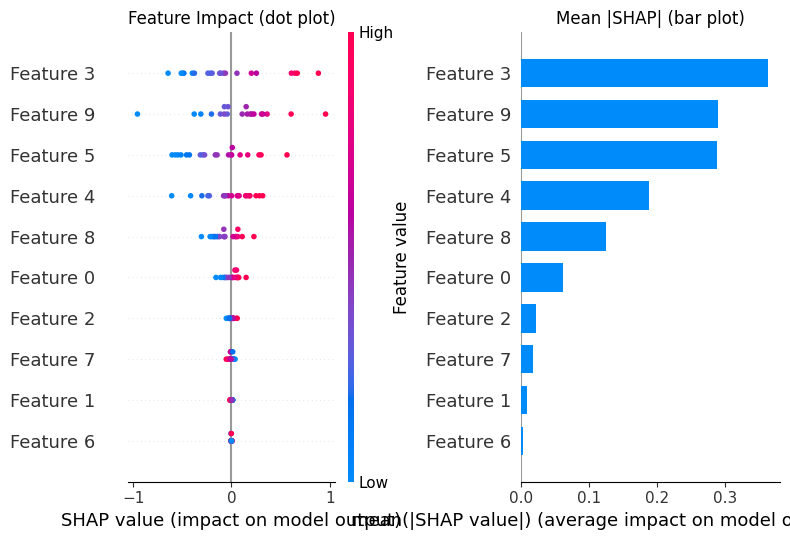

In [29]:
try:
    import shap

    # Background data for expected-value estimation
    background_tensor = torch.tensor(X_train[:50], dtype=torch.float32)
    test_tensor = torch.tensor(X_test[:20], dtype=torch.float32)

    explainer = shap.GradientExplainer(node_shap.module_, background_tensor)
    shap_values = explainer.shap_values(test_tensor)

    # Squeeze if extra dim present (single-target regression)
    if hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
        shap_values = shap_values.squeeze(-1)

    print(f"SHAP values shape: {shap_values.shape}")

    # --- Summary dot-plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_test[:20], show=False)
    axes[0].set_title("Feature Impact (dot plot)")

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test[:20], plot_type="bar", show=False)
    axes[1].set_title("Mean |SHAP| (bar plot)")

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.2 Waterfall plot — explaining a single prediction

The waterfall plot shows how each feature pushes the prediction away from the
base value (average model output on the background set).

Sample 0  —  true=-0.05  pred=0.06


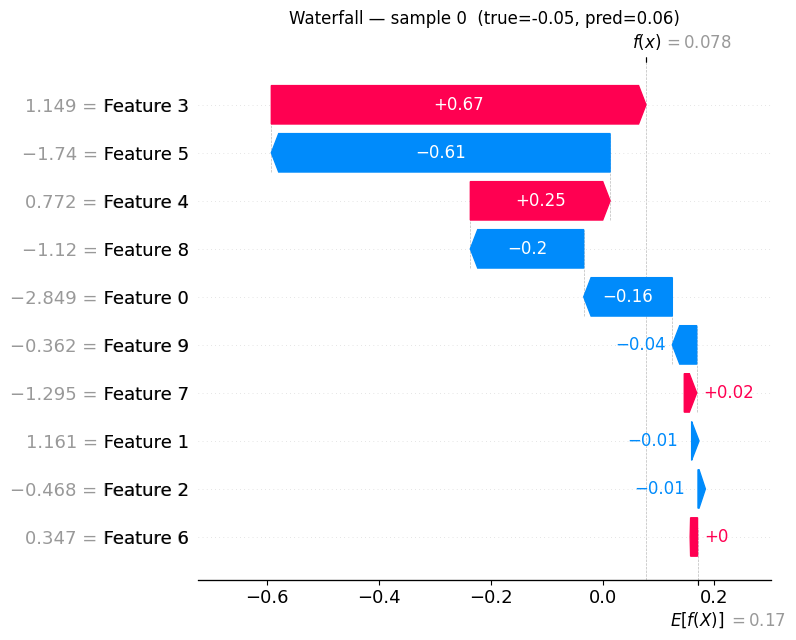

In [30]:
try:
    import shap

    sample_idx = 0
    sample_shap = shap_values[sample_idx]

    # Base value = mean model output on background
    with torch.no_grad():
        base_value = float(node_shap.module_(background_tensor).cpu().numpy().mean())

    explanation = shap.Explanation(
        values=sample_shap,
        base_values=base_value,
        data=X_test[sample_idx],
    )

    pred = float(node_shap.predict(X_test[sample_idx : sample_idx + 1])[0])
    true = float(y_test[sample_idx])
    print(f"Sample {sample_idx}  —  true={true:.2f}  pred={pred:.2f}")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, show=False)
    plt.title(f"Waterfall — sample {sample_idx}  (true={true:.2f}, pred={pred:.2f})")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.3 SHAP with MLP head

`GradientExplainer` also works with the MLP head — the autograd tape handles
the extra linear + BatchNorm + activation layers seamlessly.

MLP-head R²: 0.985


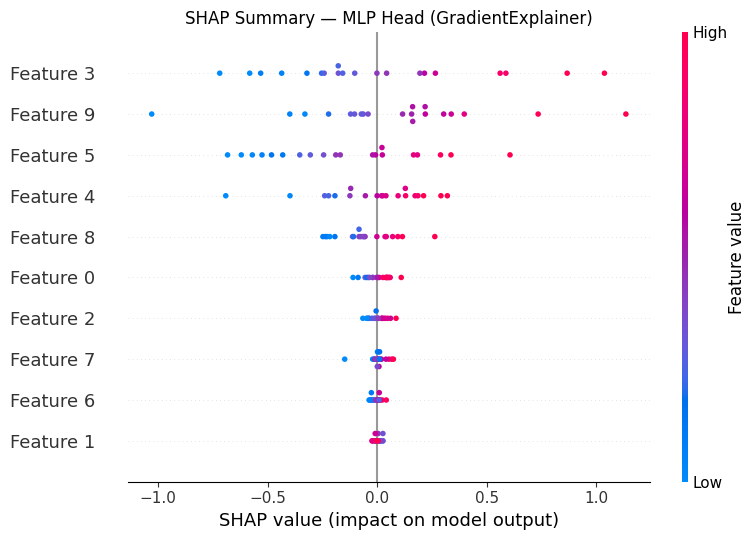

✅ GradientExplainer works with all NODE head types!


In [31]:
try:
    import shap

    node_mlp_shap = NODERegressor(
        num_trees=256,
        depth=4,
        head_type="mlp",
        mlp_hidden_dims=[64, 32],
        max_epochs=20,
        lr=0.01,
        device="cpu",
        verbose=0,
    )
    node_mlp_shap.fit(X_train, y_train)
    print(f"MLP-head R²: {r2_score(y_test, node_mlp_shap.predict(X_test)):.3f}")

    explainer_mlp = shap.GradientExplainer(
        node_mlp_shap.module_,
        torch.tensor(X_train[:50], dtype=torch.float32),
    )
    shap_mlp = explainer_mlp.shap_values(
        torch.tensor(X_test[:20], dtype=torch.float32),
    )
    if hasattr(shap_mlp, "shape") and len(shap_mlp.shape) == 3:
        shap_mlp = shap_mlp.squeeze(-1)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_mlp, X_test[:20], show=False)
    plt.title("SHAP Summary — MLP Head (GradientExplainer)")
    plt.tight_layout()
    plt.show()
    print("✅ GradientExplainer works with all NODE head types!")

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.4 KernelExplainer — model-agnostic fallback

For **flow heads** (which return distributions, not point predictions),
use `KernelExplainer` with the model's `predict` method.
It is slower but works with *any* head type.

  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

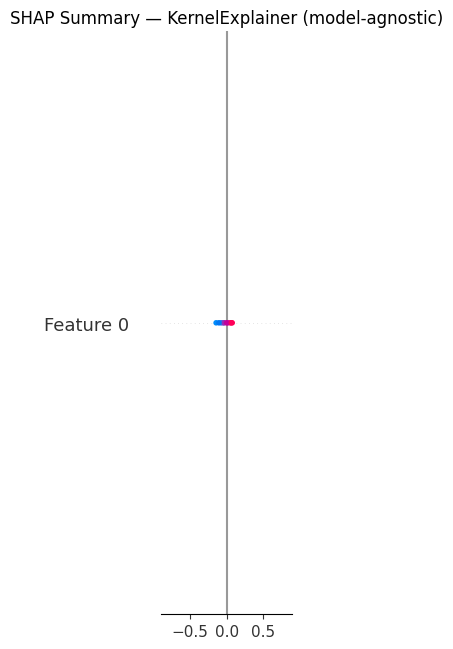

💡 Tip: Use KernelExplainer for flow heads where GradientExplainer
   cannot be applied (flow heads return distributions, not tensors).


In [32]:
try:
    import shap

    background = shap.kmeans(X_train, 50)
    kernel_explainer = shap.KernelExplainer(node_shap.predict, background)

    # Explain a handful of test samples
    shap_kernel = kernel_explainer.shap_values(X_test[:10])
    # Ensure 2-D array (some shap versions return a list for single-output)
    if isinstance(shap_kernel, list):
        shap_kernel = shap_kernel[0]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_kernel, X_test[:10], show=False)
    plt.title("SHAP Summary — KernelExplainer (model-agnostic)")
    plt.tight_layout()
    plt.show()

    print("💡 Tip: Use KernelExplainer for flow heads where GradientExplainer")
    print("   cannot be applied (flow heads return distributions, not tensors).")

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.5 Detailed SHAP Visualizations

Below we combine the GradientExplainer SHAP values (computed in §12.1) into
richer plots:

- **Beeswarm** — density-aware dot plot of per-feature SHAP impacts
- **Heatmap** — sample × feature SHAP matrix
- **Dependence plot** — SHAP value vs. feature value for a single feature, coloured by the strongest interaction

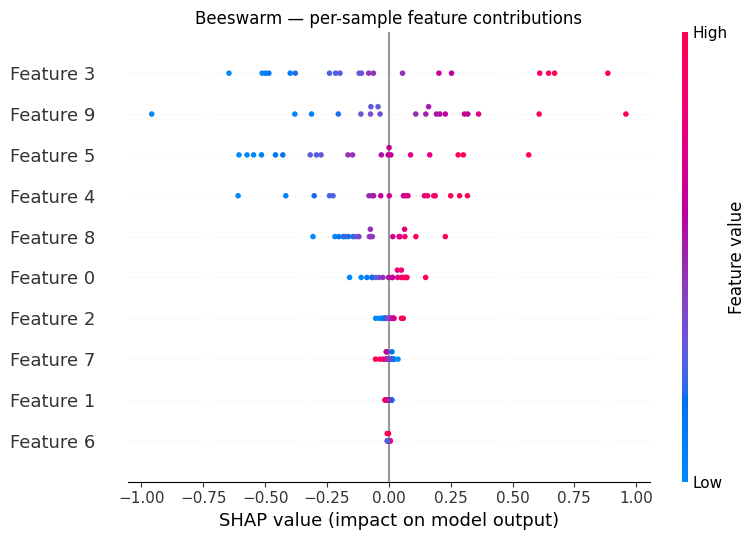

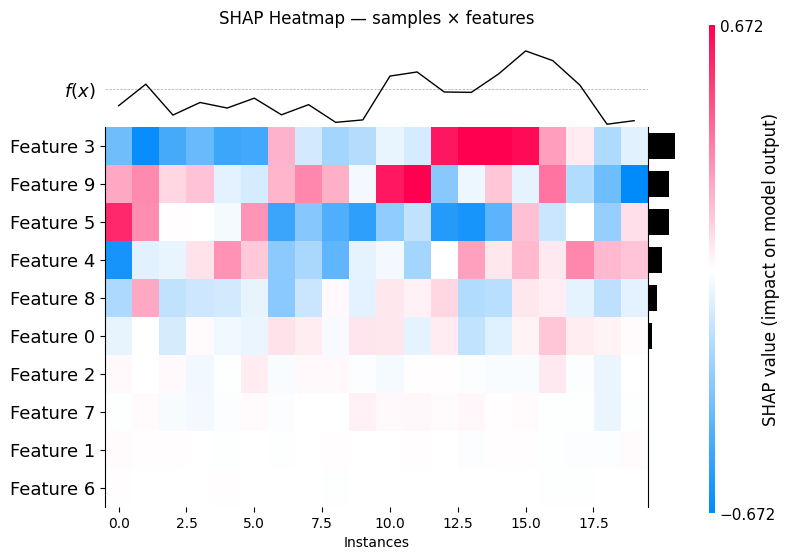

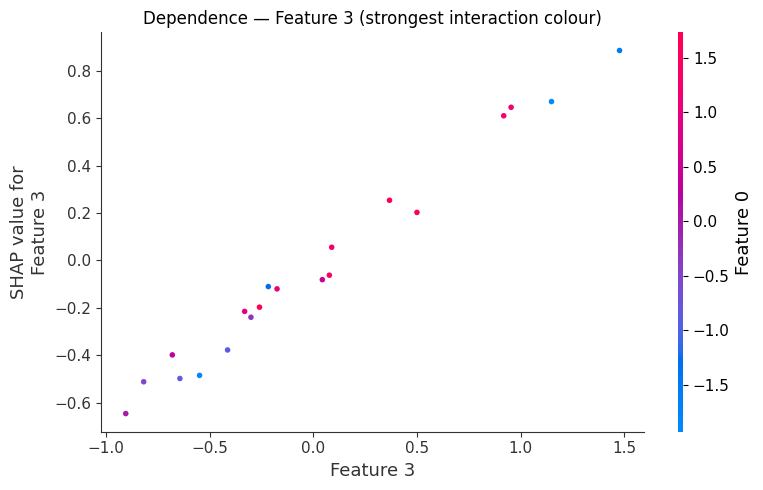

✅ All SHAP visualizations rendered successfully.


In [33]:
try:
    import shap

    # Build a proper SHAP Explanation object from the GradientExplainer results
    # (shap_values and X_test[:20] were computed in §12.1)
    with torch.no_grad():
        base_val = float(node_shap.module_(torch.tensor(X_train[:50], dtype=torch.float32)).cpu().numpy().mean())

    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]
    explanation = shap.Explanation(
        values=shap_values,  # (20, 10)
        base_values=np.full(20, base_val),
        data=X_test[:20],
        feature_names=feature_names,
    )

    # --- 1. Beeswarm plot (density-aware dot plot) ---
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.beeswarm(explanation, show=False)
    plt.title("Beeswarm — per-sample feature contributions")
    plt.tight_layout()
    plt.show()

    # --- 2. Heatmap (sample × feature matrix) ---
    fig, ax = plt.subplots(figsize=(12, 6))
    shap.plots.heatmap(explanation, show=False)
    plt.title("SHAP Heatmap — samples × features")
    plt.tight_layout()
    plt.show()

    # --- 3. Dependence plot for the most important feature ---
    top_feature = int(np.abs(shap_values).mean(axis=0).argmax())
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        top_feature,
        shap_values,
        X_test[:20],
        feature_names=feature_names,
        ax=ax,
        show=False,
    )
    ax.set_title(f"Dependence — {feature_names[top_feature]} (strongest interaction colour)")
    plt.tight_layout()
    plt.show()

    print("✅ All SHAP visualizations rendered successfully.")

except ImportError:
    print("Install shap for explanations:  pip install shap")

---
## 13  Advanced Topics

### 13.1  DataFrame & Categorical Support

NODE natively accepts **pandas DataFrames**.  Columns with `pd.Categorical` dtype are automatically detected and embedded — no manual one-hot encoding needed.

```python
import pandas as pd

df = pd.DataFrame({
    "mass":      [150.0, 220.0, 310.0],
    "logP":      [2.1, 3.5, 1.2],
    "scaffold":  pd.Categorical(["benzene", "pyridine", "benzene"]),
})

reg = NODERegressor()
reg.fit(df, y)          # scaffold auto-embedded
preds = reg.predict(df)
```

The `InputOutputShapeSetter` callback handles:
- Input dimension from `X.shape[1]`
- Categorical feature detection from column dtypes
- Label encoding and embedding dimension calculation

### 13.2  Embeddings → Standalone Head Pipeline

Use NODE's tree layers as a **feature extractor**, then feed the learned
embeddings into a standalone head or any downstream model:

```python
# 1. Train NODE
node = NODERegressor(num_trees=2048, max_epochs=100, device="cpu")
node.fit(X_train, y_train)

# 2. Extract embeddings
emb_train = node.get_embeddings(X_train)
emb_test  = node.get_embeddings(X_test)

# 3. Feed into a standalone flow head for probabilistic output
flow = FlowHeadRegressor(flow_type="NSF", max_epochs=200)
flow.fit(emb_train, y_train)
samples = flow.predict_flow(emb_test, num_samples=500)
```

This two-stage approach lets you decouple representation learning from the
prediction head, or reuse expensive embeddings with multiple heads.

### 13.3  Skorch Integration

NODE estimators are built on [skorch](https://github.com/skorch-dev/skorch),
so all skorch features work out of the box — custom callbacks, learning-rate
schedulers, validation splits, etc.

```python
from skorch.callbacks import EarlyStopping, LRScheduler

reg = NODERegressor(
    callbacks=[
        EarlyStopping(patience=10, monitor="valid_loss"),
        LRScheduler(policy="CosineAnnealingLR", T_max=50),
    ],
    train_split=skorch.dataset.ValidSplit(cv=0.15),
)
```

### 13.4  Device Management

```python
# Auto-detect GPU (uses CUDA if available, else CPU)
reg = NODERegressor()

# Force CPU (useful for CI / small models)
reg = NODERegressor(device="cpu")

# Specify a particular GPU
reg = NODERegressor(device="cuda:0")
```

### 13.5  MC Dropout — Implementation Details

NODE's MC Dropout implementation is carefully designed:

1. **BatchNorm stays in eval mode** — uses running statistics, not batch statistics
2. **Only `nn.Dropout` modules switch to train mode** for stochastic forward passes
3. **`temporary_dropout_override`** — context manager lets you use a different
   dropout rate for UQ than the one used during training

This means `predict_uncertainty()` gives reliable estimates without
retraining.

### 13.6  Interface Compatibility with Other Mother Estimators

NODE's `predict_uncertainty()` uses the same signature as TabPFN, RandomForest,
and CatBoost on the `ranker_update` branch:

```python
# All Mother estimators share this interface:
results = model.predict_uncertainty(X)
#   → DataFrame with: mean_predictions, knowledge_uncertainty,
#                      data_uncertainty, total_uncertainty

results, q = model.predict_uncertainty(
    X, return_quantiles=True, quantiles=[0.025, 0.5, 0.975],
)
#   → (DataFrame, ndarray of shape (n_samples, n_quantiles))

unc = model.predict_uncertainty(X, uncertainty_for_opt=True)
#   → pd.Series of total_uncertainty (for optimisation loops)
```

NODE additionally provides `predict_quantiles()` as a convenience shorthand and
`predict_with_combined_uncertainty()` for flow-head decomposition.

---
## 14  Hyperparameter Tuning with MotherTuner

NODE integrates with Mother's `MotherTuner` for automated hyperparameter optimisation via Optuna.

The tuner automatically suggests sensible ranges for:
- `num_trees`, `depth`, `num_layers` (architecture)
- `input_dropout`, `tree_dropout` (regularisation)
- `lr` (optimisation)
- Head-specific params: `mlp_hidden_dims`, `flow_type`, `flow_transforms` (if `tune_head=True`)

| Parameter | Range | Scale |
|-----------|-------|-------|
| `num_trees` | 256 – 4096 | log |
| `depth` | 3 – 8 | linear |
| `num_layers` | 1 – 3 | linear |
| `input_dropout` | 0.0 – 0.3 | linear |
| `tree_dropout` | 0.0 – 0.5 | linear |
| `lr` | 1e-4 – 1e-1 | log |
| `head_type` | mlp / subset / linear / flow | categorical |

```python
from mother.optimization import MotherTuner

tuner = MotherTuner(
    estimator=NODERegressor(max_epochs=50, device="cpu"),
    X=X_train,
    y=y_train,
    n_trials=30,
    scoring="neg_mean_squared_error",
)
tuner.run()

print(f"Best params: {tuner.best_params}")
print(f"Best score:  {tuner.best_score}")

# Get the best model
best_model = tuner.best_estimator
```

**Tip:** Set `tune_head=True` (default) in the estimator constructor to also optimise the head architecture.

---
## Summary

| Feature | API |
|---------|-----|
| Regression | `NODERegressor(head_type="mlp").fit(X, y).predict(X)` |
| Classification | `NODEClassifier(head_type="subset").fit(X, y).predict(X)` |
| Multi-label classification | `NODEClassifier(model_type="classification_multilabel", criterion=BCEWithLogitsLoss)` |
| Probabilistic regression | `NODERegressor(head_type="flow", flow_type="NSF")` |
| Uncertainty (standardised) | `.predict_uncertainty(X, num_samples=100)` → DataFrame |
| Uncertainty + quantiles | `.predict_uncertainty(X, return_quantiles=True, quantiles=[...])` → `(DataFrame, ndarray)` |
| Uncertainty for optimisation | `.predict_uncertainty(X, uncertainty_for_opt=True)` → `pd.Series` |
| Quantile shorthand | `.predict_quantiles(X, quantiles=[0.025, 0.5, 0.975])` → ndarray |
| Combined UQ decomposition | `.predict_with_combined_uncertainty(X)` (flow only) |
| Embeddings | `.get_embeddings(X)` |
| DataFrame / categoricals | `reg.fit(df, y)` — auto-embeds `pd.Categorical` columns |
| Embeddings → head pipeline | `FlowHeadRegressor().fit(node.get_embeddings(X), y)` |
| Standalone MLP (reg) | `MLPHeadRegressor(hidden_dims=[128,64])` |
| Standalone MLP (clf) | `MLPHeadClassifier(hidden_dims=[128,64])` |
| Standalone Flow (reg) | `FlowHeadRegressor(flow_type="NSF")` |
| Hyperparameter tuning | `MotherTuner(estimator=NODERegressor(), ...)` |
| SHAP explanations | `shap.GradientExplainer(model.module_, background)` |
| Skorch callbacks | `NODERegressor(callbacks=[EarlyStopping(...), LRScheduler(...)])` |